In [1]:
from warnings import filterwarnings; filterwarnings("ignore")
import joblib
import pandas as pd
import numpy as np
import pandas, numpy
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor, Pool
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import StackingRegressor

from sklearn.linear_model import RidgeCV
from sklearn.linear_model import ElasticNetCV
from sklearn.linear_model import LassoCV
from sklearn.linear_model import LassoLars

from sklearn.metrics import mean_absolute_percentage_error
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.ensemble import VotingRegressor, BaggingRegressor
from sklearn.base import BaseEstimator, RegressorMixin
from scipy.optimize import minimize
from sklearn.metrics import r2_score

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import (
    SelectKBest, f_regression, mutual_info_regression,
    RFE, SelectFromModel, VarianceThreshold
)
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
from scipy.stats import pearsonr, spearmanr
from scipy.cluster.hierarchy import linkage, fcluster
import warnings
warnings.filterwarnings('ignore')

class DataPreprocessing:
    def __init__(self, train, test):
        self.target = "ghi"
        self.column_drop = "timestamp"
        
        self.train_original = train.copy()
        self.test_original = test.copy()
        
        if 'Unnamed: 0' in train.columns:
            self.train = train.drop(columns=['Unnamed: 0'])
            self.test = test.drop(columns=['Unnamed: 0'])
        else:
            self.train = train.copy()
            self.test = test.copy()

        self.train = self.train.dropna(subset=['timestamp'])
        self.test = self.test.dropna(subset=['timestamp'])

        self.feature_extraction()
        self.handle_solar_specific_features()
        self.handle_missing_values()
        self.train_test_split()
        self.golden_feature_selection()
        self.normalise_encode()
        
    def feature_extraction(self):
        """Advanced feature extraction for solar forecasting with astronomical and meteorological features"""
        self.train['timestamp'] = pd.to_datetime(self.train['timestamp'])
        self.test['timestamp'] = pd.to_datetime(self.test['timestamp'])
        
        for df in [self.train, self.test]:
            df['timestamp_year'] = df['timestamp'].dt.year
            df['timestamp_month'] = df['timestamp'].dt.month
            df['timestamp_day'] = df['timestamp'].dt.day
            df['timestamp_hour'] = df['timestamp'].dt.hour
            df['timestamp_minute'] = df['timestamp'].dt.minute
            
            df['day_of_year'] = df['timestamp'].dt.dayofyear
            df['week_of_year'] = df['timestamp'].dt.isocalendar().week
            df['day_of_week'] = df['timestamp'].dt.dayofweek
            df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
            df['quarter'] = df['timestamp'].dt.quarter
            
            df['is_morning'] = ((df['timestamp_hour'] >= 6) & (df['timestamp_hour'] < 12)).astype(int)
            df['is_afternoon'] = ((df['timestamp_hour'] >= 12) & (df['timestamp_hour'] < 18)).astype(int)
            df['is_evening'] = ((df['timestamp_hour'] >= 18) & (df['timestamp_hour'] < 22)).astype(int)
            df['is_night'] = ((df['timestamp_hour'] >= 22) | (df['timestamp_hour'] < 6)).astype(int)
            
            df['is_peak_solar'] = ((df['timestamp_hour'] >= 10) & (df['timestamp_hour'] <= 16)).astype(int)
            df['hours_from_solar_noon'] = np.abs(df['timestamp_hour'] - 12)
            
            df['hour_sin'] = np.sin(2 * np.pi * df['timestamp_hour'] / 24)
            df['hour_cos'] = np.cos(2 * np.pi * df['timestamp_hour'] / 24)
            df['day_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
            df['day_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25)
            df['month_sin'] = np.sin(2 * np.pi * df['timestamp_month'] / 12)
            df['month_cos'] = np.cos(2 * np.pi * df['timestamp_month'] / 12)
            df['week_sin'] = np.sin(2 * np.pi * df['week_of_year'] / 52)
            df['week_cos'] = np.cos(2 * np.pi * df['week_of_year'] / 52)
            df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
            df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
            
            df['season'] = ((df['timestamp_month'] % 12) // 3)
            
            df['is_summer'] = (df['season'] == 1).astype(int)
            df['is_winter'] = (df['season'] == 3).astype(int)
            df['is_spring'] = (df['season'] == 0).astype(int)
            df['is_autumn'] = (df['season'] == 2).astype(int)
            
            df['is_monsoon'] = ((df['timestamp_month'] >= 6) & (df['timestamp_month'] <= 9)).astype(int)
            df['is_winter_solstice_period'] = ((df['timestamp_month'] == 12) | (df['timestamp_month'] == 1)).astype(int)
            df['is_summer_solstice_period'] = ((df['timestamp_month'] == 6) | (df['timestamp_month'] == 7)).astype(int)
            df['is_equinox_period'] = ((df['timestamp_month'] == 3) | (df['timestamp_month'] == 9)).astype(int)
            
            df['solar_declination'] = 23.45 * np.sin(np.radians(360 * (284 + df['day_of_year']) / 365))
            
            df['hour_angle'] = 15 * (df['timestamp_hour'] - 12)
            
            latitude = 23.0
            df['solar_elevation'] = np.arcsin(
                np.sin(np.radians(latitude)) * np.sin(np.radians(df['solar_declination'])) +
                np.cos(np.radians(latitude)) * np.cos(np.radians(df['solar_declination'])) * 
                np.cos(np.radians(df['hour_angle']))
            ) * 180 / np.pi
            
            df['solar_elevation_positive'] = np.maximum(df['solar_elevation'], 0)
            
            df['air_mass'] = np.where(
                df['solar_elevation_positive'] > 0,
                1 / (np.sin(np.radians(df['solar_elevation_positive'])) + 
                     0.50572 * (df['solar_elevation_positive'] + 6.07995) ** -1.6364),
                np.inf
            )
            df['air_mass'] = np.where(df['air_mass'] == np.inf, 50, df['air_mass'])
            df['air_mass'] = np.minimum(df['air_mass'], 50)
            
            solar_constant = 1367
            df['extraterrestrial_radiation'] = solar_constant * (
                1 + 0.033 * np.cos(2 * np.pi * df['day_of_year'] / 365)
            ) * np.maximum(np.sin(np.radians(df['solar_elevation'])), 0)
            
            df['theoretical_clear_sky_ghi'] = df['extraterrestrial_radiation'] * 0.75 ** (df['air_mass'] ** 0.678)
            
            turbidity_factor = 2.0
            
            rayleigh_coefficient = np.where(df['air_mass'] <= 20, 
                                          1 / (6.6296 + 1.7513 * df['air_mass'] - 0.1202 * df['air_mass']**2 + 
                                               0.0065 * df['air_mass']**3 - 0.00013 * df['air_mass']**4), 0)
            
            aerosol_coefficient = np.exp(-0.8662 * turbidity_factor * df['air_mass'])
            
            df['clear_sky_ghi_ineichen'] = df['extraterrestrial_radiation'] * \
                                         np.sin(np.radians(df['solar_elevation_positive'])) * \
                                         rayleigh_coefficient * aerosol_coefficient
            
            linke_turbidity = 3.5
            
            delta_r = 1 + 0.033 * np.cos(2 * np.pi * df['day_of_year'] / 365)
            df['clear_sky_ghi_esra'] = df['extraterrestrial_radiation'] * delta_r * \
                                     np.exp(-0.8662 * linke_turbidity * df['air_mass'] * 
                                            (1 + df['air_mass'] - (df['air_mass'])**1.06))
            
            clear_sky_models = ['theoretical_clear_sky_ghi', 'clear_sky_ghi_ineichen', 'clear_sky_ghi_esra']
            df['clear_sky_ghi_ensemble'] = df[clear_sky_models].mean(axis=1)
            
            if 'irradiance_horizontal' in df.columns:
                for model in clear_sky_models + ['clear_sky_ghi_ensemble']:
                    df[f'clearness_index_{model}'] = df['irradiance_horizontal'] / (df[model] + 1e-6)
                    df[f'clearness_index_{model}'] = np.clip(df[f'clearness_index_{model}'], 0, 2)
            
            df['potential_sunshine_hours'] = np.where(df['solar_elevation_positive'] > 0, 1, 0)
            
            df['hour_of_day_numeric'] = df['timestamp_hour'] + df['timestamp_minute'] / 60.0
            
            df['days_since_winter_solstice'] = np.where(
                df['day_of_year'] >= 355,
                df['day_of_year'] - 355,
                df['day_of_year'] + 10
            )
            
            df['days_since_summer_solstice'] = np.where(
                df['day_of_year'] >= 172,
                df['day_of_year'] - 172,
                df['day_of_year'] + 193
            )
            
            df['solar_intensity_category'] = 0
            df.loc[(df['timestamp_hour'].between(6, 8)) | (df['timestamp_hour'].between(16, 18)), 'solar_intensity_category'] = 1
            df.loc[(df['timestamp_hour'].between(9, 11)) | (df['timestamp_hour'].between(13, 15)), 'solar_intensity_category'] = 2
            df.loc[df['timestamp_hour'].between(11, 13), 'solar_intensity_category'] = 3
            
            df['hour_season_interaction'] = df['timestamp_hour'] * df['season']
            df['day_of_year_hour_interaction'] = df['day_of_year'] * df['timestamp_hour'] / 365.25

    def handle_solar_specific_features(self):
        """Advanced solar-specific feature engineering with comprehensive meteorological and physical relationships"""
        for df in [self.train, self.test]:
            df['minutes_since_midnight'] = df['timestamp_hour'] * 60 + df['timestamp_minute']
            df['minutes_since_solar_noon'] = np.abs(df['minutes_since_midnight'] - 720)
            
            latitude_rad = np.radians(23.0)
            declination_rad = np.radians(df['solar_declination'])
            
            cos_hour_angle = -np.tan(latitude_rad) * np.tan(declination_rad)
            cos_hour_angle = np.clip(cos_hour_angle, -1, 1)
            sunrise_hour_angle = np.degrees(np.arccos(cos_hour_angle))
            
            df['daylight_duration_hours'] = 2 * sunrise_hour_angle / 15
            df['sunrise_time'] = 12 - df['daylight_duration_hours'] / 2
            df['sunset_time'] = 12 + df['daylight_duration_hours'] / 2
            
            df['time_since_sunrise'] = df['timestamp_hour'] - df['sunrise_time']
            df['time_until_sunset'] = df['sunset_time'] - df['timestamp_hour']
            df['is_daylight'] = ((df['timestamp_hour'] >= df['sunrise_time']) & 
                               (df['timestamp_hour'] <= df['sunset_time'])).astype(int)
            
            df['solar_day_fraction'] = np.where(
                df['is_daylight'],
                (df['timestamp_hour'] - df['sunrise_time']) / df['daylight_duration_hours'],
                0
            )
            
            df['is_dawn'] = ((df['timestamp_hour'] >= (df['sunrise_time'] - 1)) & 
                            (df['timestamp_hour'] < df['sunrise_time'])).astype(int)
            df['is_dusk'] = ((df['timestamp_hour'] > df['sunset_time']) & 
                            (df['timestamp_hour'] <= (df['sunset_time'] + 1))).astype(int)
            
            df['is_high_efficiency_window'] = ((df['timestamp_hour'] >= 9) & 
                                             (df['timestamp_hour'] <= 15)).astype(int)
            df['is_moderate_efficiency_window'] = (((df['timestamp_hour'] >= 7) & 
                                                  (df['timestamp_hour'] < 9)) |
                                                 ((df['timestamp_hour'] > 15) & 
                                                  (df['timestamp_hour'] <= 17))).astype(int)
            
            df['minute_sin'] = np.sin(2 * np.pi * df['timestamp_minute'] / 60)
            df['minute_cos'] = np.cos(2 * np.pi * df['timestamp_minute'] / 60)
            
            df['solar_noon_proximity'] = 1 / (1 + df['hours_from_solar_noon'])
            
            if 'irradiance_horizontal' in df.columns and 'irradiance_global_reference' in df.columns:
                df['irradiance_ratio'] = df['irradiance_horizontal'] / (df['irradiance_global_reference'] + 1e-6)
                df['irradiance_difference'] = df['irradiance_global_reference'] - df['irradiance_horizontal']
                df['irradiance_deficit'] = np.maximum(0, df['irradiance_difference'])
                
                df['atmospheric_transmission_coeff'] = np.clip(df['irradiance_ratio'], 0, 1)
                
                df['estimated_cloud_cover'] = 1 - df['atmospheric_transmission_coeff']
                
                clearness_bins = [0, 0.3, 0.6, 0.8, 2.0]
                df['clearness_category'] = pd.cut(df['irradiance_ratio'], 
                                                bins=clearness_bins, 
                                                labels=[0, 1, 2, 3], 
                                                include_lowest=True)
                df['clearness_category'] = df['clearness_category'].fillna(1).astype(int)
                
                df['irradiance_rate_of_change'] = df['irradiance_horizontal'].diff().fillna(0)
                df['irradiance_volatility'] = np.abs(df['irradiance_rate_of_change'])
                
                df['is_peak_irradiance'] = (df['irradiance_horizontal'] > 800).astype(int)
                df['is_low_irradiance'] = (df['irradiance_horizontal'] < 200).astype(int)
            
            horizontal_rad_cols = [col for col in df.columns if 'horizontal_radiation' in col]
            incident_rad_cols = [col for col in df.columns if 'incident_radiation' in col]
            reflected_rad_cols = [col for col in df.columns if 'reflected_radiation' in col]
            
            if horizontal_rad_cols and len(horizontal_rad_cols) > 1:
                df['horizontal_radiation_mean'] = df[horizontal_rad_cols].mean(axis=1)
                df['horizontal_radiation_std'] = df[horizontal_rad_cols].std(axis=1).fillna(0)
                df['horizontal_radiation_max'] = df[horizontal_rad_cols].max(axis=1)
                df['horizontal_radiation_min'] = df[horizontal_rad_cols].min(axis=1)
                df['horizontal_radiation_range'] = df['horizontal_radiation_max'] - df['horizontal_radiation_min']
                df['horizontal_radiation_median'] = df[horizontal_rad_cols].median(axis=1)
                
                df['horizontal_radiation_cv'] = (df['horizontal_radiation_std'] / 
                                               (df['horizontal_radiation_mean'] + 1e-6))
                
                df['horizontal_sensor_agreement'] = 1 / (1 + df['horizontal_radiation_cv'])
                
                df['horizontal_sensor_spread'] = df['horizontal_radiation_range'] / (df['horizontal_radiation_mean'] + 1e-6)
                
                df['horizontal_outlier_count'] = 0
                for col in horizontal_rad_cols:
                    if col in df.columns:
                        z_score = np.abs((df[col] - df['horizontal_radiation_mean']) / (df['horizontal_radiation_std'] + 1e-6))
                        df['horizontal_outlier_count'] += (z_score > 2).astype(int)
                
                df['horizontal_fusion_quality'] = (df['horizontal_sensor_agreement'] * 
                                                 (1 - np.clip(df['horizontal_sensor_spread'], 0, 1)) * 
                                                 (1 - df['horizontal_outlier_count'] / len(horizontal_rad_cols)))
                
                if 'clear_sky_ghi_ensemble' in df.columns:
                    df['horizontal_radiation_efficiency'] = (df['horizontal_radiation_mean'] / 
                                                           (df['clear_sky_ghi_ensemble'] + 1e-6))
                    df['horizontal_radiation_efficiency'] = np.clip(df['horizontal_radiation_efficiency'], 0, 2)
            elif len(horizontal_rad_cols) == 1:
                df['horizontal_radiation_mean'] = df[horizontal_rad_cols[0]]
                df['horizontal_radiation_cv'] = 0
                df['horizontal_sensor_agreement'] = 1
                df['horizontal_fusion_quality'] = 1
            
            if incident_rad_cols and len(incident_rad_cols) > 1:
                df['incident_radiation_mean'] = df[incident_rad_cols].mean(axis=1)
                df['incident_radiation_std'] = df[incident_rad_cols].std(axis=1).fillna(0)
                df['incident_radiation_max'] = df[incident_rad_cols].max(axis=1)
                df['incident_radiation_min'] = df[incident_rad_cols].min(axis=1)
                df['incident_radiation_skew'] = df[incident_rad_cols].skew(axis=1).fillna(0)
                df['incident_radiation_median'] = df[incident_rad_cols].median(axis=1)
                
                df['incident_radiation_cv'] = (df['incident_radiation_std'] / 
                                             (df['incident_radiation_mean'] + 1e-6))
                
                df['incident_radiation_concentration'] = (df['incident_radiation_max'] / 
                                                        (df['incident_radiation_mean'] + 1e-6))
                
                df['incident_radiation_uniformity'] = 1 - df['incident_radiation_cv']
                df['incident_sensor_agreement'] = 1 / (1 + df['incident_radiation_cv'])
                
                df['incident_directional_balance'] = 1 - np.abs(df['incident_radiation_skew'])
            elif len(incident_rad_cols) == 1:
                df['incident_radiation_mean'] = df[incident_rad_cols[0]]
                df['incident_radiation_cv'] = 0
                df['incident_sensor_agreement'] = 1
                df['incident_radiation_uniformity'] = 1
            
            if reflected_rad_cols and len(reflected_rad_cols) > 1:
                df['reflected_radiation_mean'] = df[reflected_rad_cols].mean(axis=1)
                df['reflected_radiation_std'] = df[reflected_rad_cols].std(axis=1).fillna(0)
                df['reflected_radiation_sum'] = df[reflected_rad_cols].sum(axis=1)
                df['reflected_radiation_max'] = df[reflected_rad_cols].max(axis=1)
                
                if 'horizontal_radiation_mean' in df.columns:
                    df['ground_albedo'] = (df['reflected_radiation_mean'] / 
                                         (df['horizontal_radiation_mean'] + 1e-6))
                    df['ground_albedo'] = np.clip(df['ground_albedo'], 0, 1)
                    
                    albedo_bins = [0, 0.1, 0.3, 0.6, 1.0]
                    df['albedo_category'] = pd.cut(df['ground_albedo'], 
                                                 bins=albedo_bins, 
                                                 labels=[0, 1, 2, 3], 
                                                 include_lowest=True)
                    df['albedo_category'] = df['albedo_category'].fillna(1).astype(int)
                    
                    df['surface_water_like'] = (df['ground_albedo'] < 0.1).astype(int)
                    df['surface_vegetation_like'] = ((df['ground_albedo'] >= 0.1) & (df['ground_albedo'] < 0.3)).astype(int)
                    df['surface_soil_like'] = ((df['ground_albedo'] >= 0.3) & (df['ground_albedo'] < 0.6)).astype(int)
                    df['surface_sand_like'] = (df['ground_albedo'] >= 0.6).astype(int)
                    
                    df['albedo_rolling_mean'] = df['ground_albedo'].rolling(window=5, center=True).mean().fillna(df['ground_albedo'])
                    df['albedo_stability'] = 1 - np.abs(df['ground_albedo'] - df['albedo_rolling_mean'])
                    
                    df['albedo_summer_adjusted'] = df['ground_albedo'] * (1 + 0.1 * df['is_summer'])
                    df['albedo_monsoon_adjusted'] = df['ground_albedo'] * (1 - 0.15 * df['is_monsoon'])
            elif len(reflected_rad_cols) == 1:
                df['reflected_radiation_mean'] = df[reflected_rad_cols[0]]
                if 'horizontal_radiation_mean' in df.columns:
                    df['ground_albedo'] = (df['reflected_radiation_mean'] / 
                                         (df['horizontal_radiation_mean'] + 1e-6))
                    df['ground_albedo'] = np.clip(df['ground_albedo'], 0, 1)
            
            if 'horizontal_radiation_mean' in df.columns and 'incident_radiation_mean' in df.columns:
                df['horizontal_incident_ratio'] = (df['horizontal_radiation_mean'] / 
                                                 (df['incident_radiation_mean'] + 1e-6))
                df['radiation_directional_factor'] = df['incident_radiation_mean'] - df['horizontal_radiation_mean']
                
                total_radiation = df['horizontal_radiation_mean'] + df['incident_radiation_mean']
                if 'reflected_radiation_mean' in df.columns:
                    total_radiation += df['reflected_radiation_mean']
                    df['reflected_fraction'] = df['reflected_radiation_mean'] / (total_radiation + 1e-6)
                
                df['horizontal_fraction'] = df['horizontal_radiation_mean'] / (total_radiation + 1e-6)
                df['incident_fraction'] = df['incident_radiation_mean'] / (total_radiation + 1e-6)
                
                df['radiation_balance_index'] = 1 - np.abs(0.5 - df['horizontal_fraction'])
            
            if 'relative_humidity' in df.columns:
                df['humidity_optimal'] = ((df['relative_humidity'] >= 30) & 
                                        (df['relative_humidity'] <= 60)).astype(int)
                df['humidity_too_high'] = (df['relative_humidity'] > 80).astype(int)
                df['humidity_too_low'] = (df['relative_humidity'] < 20).astype(int)
                
                if 'ambient_temperature' in df.columns:
                    df['saturation_vapor_pressure'] = 6.112 * np.exp(
                        (17.67 * df['ambient_temperature']) / (df['ambient_temperature'] + 243.5)
                    )
                    df['actual_vapor_pressure'] = (df['relative_humidity'] / 100) * df['saturation_vapor_pressure']
                    
                    df['vapor_pressure_deficit'] = df['saturation_vapor_pressure'] - df['actual_vapor_pressure']
                    
                    df['air_density'] = (df['actual_vapor_pressure'] * 0.3484 + 
                                       (1013.25 - df['actual_vapor_pressure']) * 0.4015) / (df['ambient_temperature'] + 273.15)
            
            if 'wind_direction' in df.columns:
                df['wind_dir_sin'] = np.sin(2 * np.pi * df['wind_direction'] / 360)
                df['wind_dir_cos'] = np.cos(2 * np.pi * df['wind_direction'] / 360)
                
                df['wind_north'] = ((df['wind_direction'] >= 337.5) | (df['wind_direction'] < 22.5)).astype(int)
                df['wind_south'] = ((df['wind_direction'] >= 157.5) & (df['wind_direction'] < 202.5)).astype(int)
                df['wind_east'] = ((df['wind_direction'] >= 67.5) & (df['wind_direction'] < 112.5)).astype(int)
                df['wind_west'] = ((df['wind_direction'] >= 247.5) & (df['wind_direction'] < 292.5)).astype(int)
            
            if 'wind_speed' in df.columns:
                df['wind_power_density'] = 0.5 * df['wind_speed'] ** 3
                
                wind_bins = [0, 1, 3, 6, 10, 20, 100]
                df['wind_impact_category'] = pd.cut(df['wind_speed'], 
                                                  bins=wind_bins, 
                                                  labels=[0, 1, 2, 3, 4, 5], 
                                                  include_lowest=True)
                df['wind_impact_category'] = df['wind_impact_category'].fillna(2).astype(int)
                
                df['wind_optimal'] = ((df['wind_speed'] >= 2) & (df['wind_speed'] <= 8)).astype(int)
                
                df['dust_clearing_potential'] = np.tanh(df['wind_speed'] / 5)
            
            if 'wind_direction' in df.columns and 'wind_speed' in df.columns:
                df['wind_from_sea'] = ((df['wind_direction'] >= 225) & (df['wind_direction'] <= 315)).astype(int)
                df['wind_from_land'] = ((df['wind_direction'] >= 45) & (df['wind_direction'] <= 135)).astype(int)
                
                df['wind_direction_sin_smooth'] = df['wind_dir_sin'].rolling(window=3, center=True).mean().fillna(df['wind_dir_sin'])
                df['wind_direction_cos_smooth'] = df['wind_dir_cos'].rolling(window=3, center=True).mean().fillna(df['wind_dir_cos'])
                df['wind_direction_stability'] = np.sqrt(df['wind_direction_sin_smooth']**2 + df['wind_direction_cos_smooth']**2)
            
            module_temp_cols = [col for col in df.columns if 'module_temperature' in col]
            if module_temp_cols:
                df['module_temp_mean'] = df[module_temp_cols].mean(axis=1)
                df['module_temp_std'] = df[module_temp_cols].std(axis=1).fillna(0)
                df['module_temp_max'] = df[module_temp_cols].max(axis=1)
                df['module_temp_min'] = df[module_temp_cols].min(axis=1)
                df['module_temp_range'] = df['module_temp_max'] - df['module_temp_min']
                df['module_temp_skew'] = df[module_temp_cols].skew(axis=1).fillna(0)
                
                df['module_temp_uniformity'] = 1 / (1 + df['module_temp_std'])
                
                df['potential_hotspot'] = (df['module_temp_range'] > 10).astype(int)
                
                if 'ambient_temperature' in df.columns:
                    df['temp_rise'] = df['module_temp_mean'] - df['ambient_temperature']
                    df['temp_rise_per_degree'] = df['temp_rise'] / (df['ambient_temperature'] + 273.15)
                    
                    df['temperature_derating_factor'] = 1 - 0.004 * np.maximum(0, df['module_temp_mean'] - 25)
                    df['temperature_derating_factor'] = np.clip(df['temperature_derating_factor'], 0.5, 1.0)
                    
                    df['thermal_stress'] = np.abs(df['module_temp_mean'] - 45)
                    df['extreme_heat_stress'] = (df['module_temp_mean'] > 70).astype(int)
                    
                    df['daily_temp_cycle'] = np.sin(2 * np.pi * (df['timestamp_hour'] + df['timestamp_minute']/60) / 24)
                    df['temp_cycle_amplitude'] = df['temp_rise'] * np.abs(df['daily_temp_cycle'])
            
            if 'ambient_temperature' in df.columns:
                df['temp_freezing_risk'] = (df['ambient_temperature'] < 0).astype(int)
                df['temp_optimal_solar'] = ((df['ambient_temperature'] >= 15) & 
                                          (df['ambient_temperature'] <= 35)).astype(int)
                df['temp_high_stress'] = (df['ambient_temperature'] > 40).astype(int)
                
                df['temp_rate_of_change'] = df['ambient_temperature'].diff().fillna(0)
                df['temp_rising_fast'] = (df['temp_rate_of_change'] > 3).astype(int)
                df['temp_falling_fast'] = (df['temp_rate_of_change'] < -3).astype(int)
                
                if 'relative_humidity' in df.columns:
                    df['apparent_temperature'] = df['ambient_temperature'] + 0.33 * (df['actual_vapor_pressure'] if 'actual_vapor_pressure' in df.columns else df['relative_humidity'] * 0.1) - 4
            
            efficiency_factors = []
            efficiency_names = []
            
            if 'temperature_derating_factor' in df.columns:
                efficiency_factors.append(df['temperature_derating_factor'])
                efficiency_names.append('temperature')
            elif 'module_temp_mean' in df.columns:
                df['temp_efficiency_factor'] = 1 - 0.004 * np.maximum(0, df['module_temp_mean'] - 25)
                df['temp_efficiency_factor'] = np.clip(df['temp_efficiency_factor'], 0.5, 1.0)
                efficiency_factors.append(df['temp_efficiency_factor'])
                efficiency_names.append('temperature')
            
            if 'atmospheric_transmission_coeff' in df.columns:
                efficiency_factors.append(df['atmospheric_transmission_coeff'])
                efficiency_names.append('atmosphere')
            elif 'clearness_index_clear_sky_ghi_ensemble' in df.columns:
                atm_factor = np.clip(df['clearness_index_clear_sky_ghi_ensemble'], 0, 1)
                efficiency_factors.append(atm_factor)
                efficiency_names.append('atmosphere')
            
            if 'dust_clearing_potential' in df.columns:
                df['dust_efficiency_factor'] = 1 - 0.15 * (1 - df['dust_clearing_potential'])
                df['dust_efficiency_factor'] = np.clip(df['dust_efficiency_factor'], 0.7, 1.0)
                efficiency_factors.append(df['dust_efficiency_factor'])
                efficiency_names.append('dust')
            elif 'wind_speed' in df.columns:
                dust_clearing = np.tanh(df['wind_speed'] / 5)
                df['dust_efficiency_factor'] = 1 - 0.15 * (1 - dust_clearing)
                df['dust_efficiency_factor'] = np.clip(df['dust_efficiency_factor'], 0.7, 1.0)
                efficiency_factors.append(df['dust_efficiency_factor'])
                efficiency_names.append('dust')
            
            if 'module_temp_uniformity' in df.columns:
                efficiency_factors.append(df['module_temp_uniformity'])
                efficiency_names.append('uniformity')
            elif 'horizontal_sensor_agreement' in df.columns:
                efficiency_factors.append(df['horizontal_sensor_agreement'])
                efficiency_names.append('uniformity')
            
            if 'solar_elevation_positive' in df.columns:
                df['solar_angle_efficiency'] = np.sin(np.radians(df['solar_elevation_positive']))
                df['solar_angle_efficiency'] = np.clip(df['solar_angle_efficiency'], 0, 1)
                efficiency_factors.append(df['solar_angle_efficiency'])
                efficiency_names.append('solar_angle')
            
            if 'relative_humidity' in df.columns:
                df['humidity_efficiency_factor'] = 1 - 0.05 * np.maximum(0, (df['relative_humidity'] - 70) / 30)
                df['humidity_efficiency_factor'] = np.clip(df['humidity_efficiency_factor'], 0.9, 1.0)
                efficiency_factors.append(df['humidity_efficiency_factor'])
                efficiency_names.append('humidity')
            
            if 'air_density' in df.columns:
                df['air_density_efficiency'] = np.clip(df['air_density'] / 1.225, 0.95, 1.05)
                efficiency_factors.append(df['air_density_efficiency'])
                efficiency_names.append('air_density')
            
            if efficiency_factors:
                for i, (factor, name) in enumerate(zip(efficiency_factors, efficiency_names)):
                    df[f'efficiency_factor_{name}'] = np.clip(factor, 0.1, 1.2)
                
                combined_efficiency = np.ones(len(df))
                for factor in efficiency_factors:
                    combined_efficiency *= np.clip(factor, 0.1, 1.2)
                
                df['solar_panel_efficiency_index'] = combined_efficiency
                df['solar_panel_efficiency_index'] = np.clip(df['solar_panel_efficiency_index'], 0.1, 1.0)
                
                df['total_efficiency_loss'] = 1 - df['solar_panel_efficiency_index']
                df['efficiency_grade'] = pd.cut(df['solar_panel_efficiency_index'], 
                                              bins=[0, 0.6, 0.75, 0.9, 1.0],
                                              labels=['Poor', 'Fair', 'Good', 'Excellent'])
                df['efficiency_grade'] = df['efficiency_grade'].map({'Poor': 0, 'Fair': 1, 'Good': 2, 'Excellent': 3}).fillna(1)
                
                loss_factors = []
                for factor, name in zip(efficiency_factors, efficiency_names):
                    loss_factors.append((1 - np.clip(factor, 0, 1), name))
                
                if loss_factors:
                    max_loss_idx = np.argmax([loss[0] for loss in loss_factors], axis=0)
                    df['dominant_loss_factor_numeric'] = [max_loss_idx[i] if isinstance(max_loss_idx, np.ndarray) else max_loss_idx for i in range(len(df))]
            
            comfort_factors = []
            comfort_names = []
            
            if 'temp_optimal_solar' in df.columns:
                comfort_factors.append(df['temp_optimal_solar'])
                comfort_names.append('temperature')
            
            if 'humidity_optimal' in df.columns:
                comfort_factors.append(df['humidity_optimal'])
                comfort_names.append('humidity')
            
            if 'wind_optimal' in df.columns:
                comfort_factors.append(df['wind_optimal'])
                comfort_names.append('wind')
            
            if 'clearness_category' in df.columns:
                comfort_factors.append((df['clearness_category'] >= 2).astype(int))
                comfort_names.append('sky_clarity')
            
            if 'solar_elevation_positive' in df.columns:
                comfort_factors.append((df['solar_elevation_positive'] > 30).astype(int))
                comfort_names.append('sun_elevation')
            
            if 'weather_stability_index' in df.columns:
                comfort_factors.append((df['weather_stability_index'] > 0.7).astype(int))
                comfort_names.append('stability')
            
            if comfort_factors:
                df['meteorological_comfort_index'] = np.mean(comfort_factors, axis=0)
                df['comfort_factor_count'] = np.sum(comfort_factors, axis=0)
                
                df['comfort_level'] = pd.cut(df['meteorological_comfort_index'], 
                                           bins=[0, 0.3, 0.6, 0.8, 1.0],
                                           labels=[0, 1, 2, 3])
                df['comfort_level'] = df['comfort_level'].fillna(1).astype(int)
            
            if ('horizontal_radiation_mean' in df.columns and 
                'solar_panel_efficiency_index' in df.columns):
                df['radiation_efficiency_product'] = (df['horizontal_radiation_mean'] * 
                                                    df['solar_panel_efficiency_index'])
                df['theoretical_power_output'] = df['radiation_efficiency_product']
            
            if 'wind_speed' in df.columns and 'module_temp_mean' in df.columns:
                df['wind_cooling_effectiveness'] = (df['wind_speed'] * 
                                                  np.maximum(0, df['module_temp_mean'] - 25) / 
                                                  (df['module_temp_mean'] + 273.15))
                df['cooling_benefit_index'] = np.tanh(df['wind_cooling_effectiveness'])
            
            if ('relative_humidity' in df.columns and 
                'ambient_temperature' in df.columns):
                df['heat_humidity_stress'] = ((df['ambient_temperature'] - 25) * 
                                            (df['relative_humidity'] / 100))
                
                if 'actual_vapor_pressure' in df.columns:
                    df['dewpoint'] = (243.5 * np.log(df['actual_vapor_pressure'] / 6.112)) / \
                                   (17.67 - np.log(df['actual_vapor_pressure'] / 6.112))
                    df['dewpoint_depression'] = df['ambient_temperature'] - df['dewpoint']
            
            if ('solar_elevation_positive' in df.columns and 
                'wind_speed' in df.columns and 
                'ambient_temperature' in df.columns):
                df['solar_wind_temp_interaction'] = (df['solar_elevation_positive'] / 90) * \
                                                   (1 + df['wind_speed'] / 10) * \
                                                   (1 - np.abs(df['ambient_temperature'] - 25) / 50)
                df['solar_wind_temp_interaction'] = np.clip(df['solar_wind_temp_interaction'], 0, 2)
            
            stability_factors = []
            stability_names = []
            
            if 'irradiance_volatility' in df.columns:
                irradiance_stability = 1 / (1 + df['irradiance_volatility'] / 100)
                stability_factors.append(irradiance_stability)
                stability_names.append('irradiance')
            
            if 'temp_rate_of_change' in df.columns:
                temp_stability = 1 / (1 + np.abs(df['temp_rate_of_change']))
                stability_factors.append(temp_stability)
                stability_names.append('temperature')
            
            if 'wind_direction_stability' in df.columns:
                stability_factors.append(df['wind_direction_stability'])
                stability_names.append('wind_direction')
            
            if 'wind_speed' in df.columns:
                wind_speed_change = np.abs(df['wind_speed'].diff().fillna(0))
                wind_speed_stability = 1 / (1 + wind_speed_change)
                stability_factors.append(wind_speed_stability)
                stability_names.append('wind_speed')
            
            if 'relative_humidity' in df.columns:
                humidity_change = np.abs(df['relative_humidity'].diff().fillna(0))
                humidity_stability = 1 / (1 + humidity_change / 10)
                stability_factors.append(humidity_stability)
                stability_names.append('humidity')
            
            if stability_factors:
                df['weather_stability_index'] = np.mean(stability_factors, axis=0)
                df['stability_score'] = df['weather_stability_index'] * 100
                
                for factor, name in zip(stability_factors, stability_names):
                    df[f'stability_{name}'] = factor
                
                df['stability_level'] = pd.cut(df['weather_stability_index'],
                                             bins=[0, 0.5, 0.7, 0.85, 1.0],
                                             labels=[0, 1, 2, 3])
                df['stability_level'] = df['stability_level'].fillna(1).astype(int)
            
            rolling_vars = []
            
            if 'irradiance_horizontal' in df.columns:
                rolling_vars.append('irradiance_horizontal')
            if 'horizontal_radiation_mean' in df.columns:
                rolling_vars.append('horizontal_radiation_mean')
            if 'ambient_temperature' in df.columns:
                rolling_vars.append('ambient_temperature')
            if 'wind_speed' in df.columns:
                rolling_vars.append('wind_speed')
            if 'relative_humidity' in df.columns:
                rolling_vars.append('relative_humidity')
            if 'solar_panel_efficiency_index' in df.columns:
                rolling_vars.append('solar_panel_efficiency_index')
            
            for var in rolling_vars:
                if var in df.columns:
                    for window in [3, 6, 12]:
                        df[f'{var}_rolling_mean_{window}h'] = df[var].rolling(window=window, center=True).mean().fillna(df[var])
                        df[f'{var}_rolling_std_{window}h'] = df[var].rolling(window=window, center=True).std().fillna(0)
                        df[f'{var}_rolling_max_{window}h'] = df[var].rolling(window=window, center=True).max().fillna(df[var])
                        df[f'{var}_rolling_min_{window}h'] = df[var].rolling(window=window, center=True).min().fillna(df[var])
                    
                    df[f'{var}_deviation_from_trend_3h'] = df[var] - df[f'{var}_rolling_mean_3h']
                    df[f'{var}_deviation_from_trend_12h'] = df[var] - df[f'{var}_rolling_mean_12h']
                    
                    df[f'{var}_trend_direction'] = np.where(
                        df[f'{var}_rolling_mean_3h'] > df[f'{var}_rolling_mean_12h'], 1,
                        np.where(df[f'{var}_rolling_mean_3h'] < df[f'{var}_rolling_mean_12h'], -1, 0)
                    )
            
            for season in range(4):
                season_mask = df['season'] == season
                
                if season_mask.sum() > 0:
                    if 'horizontal_radiation_mean' in df.columns:
                        seasonal_rad_mean = df.loc[season_mask, 'horizontal_radiation_mean'].mean()
                        if seasonal_rad_mean > 0:
                            df.loc[season_mask, f'seasonal_radiation_ratio'] = (
                                df.loc[season_mask, 'horizontal_radiation_mean'] / seasonal_rad_mean
                            )
                    
                    if 'ambient_temperature' in df.columns:
                        seasonal_temp_mean = df.loc[season_mask, 'ambient_temperature'].mean()
                        df.loc[season_mask, f'seasonal_temperature_anomaly'] = (
                            df.loc[season_mask, 'ambient_temperature'] - seasonal_temp_mean
                        )
                    
                    if 'solar_panel_efficiency_index' in df.columns:
                        seasonal_eff_mean = df.loc[season_mask, 'solar_panel_efficiency_index'].mean()
                        if seasonal_eff_mean > 0:
                            df.loc[season_mask, f'seasonal_efficiency_ratio'] = (
                                df.loc[season_mask, 'solar_panel_efficiency_index'] / seasonal_eff_mean
                            )
            
            seasonal_cols = ['seasonal_radiation_ratio', 'seasonal_temperature_anomaly', 'seasonal_efficiency_ratio']
            for col in seasonal_cols:
                if col in df.columns:
                    if 'ratio' in col:
                        df[col] = df[col].fillna(1.0)
                    else:
                        df[col] = df[col].fillna(0.0)
            
            if 'timestamp_hour' in df.columns and 'season' in df.columns:
                df['season_hour_interaction'] = df['season'] * df['timestamp_hour']
                df['season_efficiency_interaction'] = df['season'] * df.get('solar_panel_efficiency_index', 0.8)
                
                df['monthly_solar_correction'] = 1 + 0.1 * np.cos(2 * np.pi * (df['timestamp_month'] - 6) / 12)

    def handle_missing_values(self):
        """Intelligent missing value handling for solar data with robust fallbacks"""
        self.train[self.target] = self.train[self.target].ffill().bfill().fillna(0)
        self.test[self.target] = self.test[self.target].ffill().bfill().fillna(0)
        
        radiation_cols = [col for col in self.train.columns if any(keyword in col.lower() for keyword in 
                         ['radiation', 'irradiance', 'ghi', 'dni', 'dhi', 'clearness', 'extraterrestrial'])]
        
        for df_name, df in [('train', self.train), ('test', self.test)]:
            night_mask = (df['timestamp_hour'] >= 18) | (df['timestamp_hour'] <= 6)
            
            for col in radiation_cols:
                if col in df.columns:
                    df.loc[night_mask, col] = df.loc[night_mask, col].fillna(0)
                    
                    day_mask = ~night_mask
                    if day_mask.sum() > 0:
                        df.loc[day_mask, col] = df.loc[day_mask, col].interpolate(method='linear', limit=3)
                        
                        if df[col].isnull().sum() > 0:
                            if 'timestamp_month' in df.columns and 'timestamp_hour' in df.columns:
                                seasonal_hourly_mean = df.groupby(['timestamp_month', 'timestamp_hour'])[col].transform('mean')
                                df[col] = df[col].fillna(seasonal_hourly_mean)
                            
                            if df[col].isnull().sum() > 0:
                                daily_mean = df.groupby('timestamp_hour')[col].transform('mean')
                                df[col] = df[col].fillna(daily_mean)
                            
                            df[col] = df[col].ffill().bfill().fillna(0)
            
            temp_cols = [col for col in df.columns if 'temperature' in col.lower()]
            for col in temp_cols:
                if col in df.columns and df[col].isnull().sum() > 0:
                    if 'timestamp_month' in df.columns and 'timestamp_hour' in df.columns:
                        temp_seasonal_mean = df.groupby(['timestamp_month', 'timestamp_hour'])[col].transform('mean')
                        df[col] = df[col].fillna(temp_seasonal_mean)
                    
                    df[col] = df[col].interpolate(method='linear', limit=6).ffill().bfill()
                    
                    if df[col].isnull().sum() > 0:
                        df[col] = df[col].fillna(df[col].mean())
            
            humidity_cols = [col for col in df.columns if 'humidity' in col.lower()]
            for col in humidity_cols:
                if col in df.columns and df[col].isnull().sum() > 0:
                    if 'timestamp_month' in df.columns and 'timestamp_hour' in df.columns:
                        humid_seasonal_mean = df.groupby(['timestamp_month', 'timestamp_hour'])[col].transform('mean')
                        df[col] = df[col].fillna(humid_seasonal_mean)
                    
                    df[col] = df[col].interpolate(method='linear', limit=4).ffill().bfill()
                    if df[col].isnull().sum() > 0:
                        df[col] = df[col].fillna(df[col].mean())
            
            wind_cols = [col for col in df.columns if 'wind' in col.lower()]
            for col in wind_cols:
                if col in df.columns and df[col].isnull().sum() > 0:
                    if 'timestamp_month' in df.columns:
                        wind_seasonal_mean = df.groupby('timestamp_month')[col].transform('mean')
                        df[col] = df[col].fillna(wind_seasonal_mean)
                    
                    df[col] = df[col].interpolate(method='linear', limit=5).ffill().bfill()
                    if df[col].isnull().sum() > 0:
                        df[col] = df[col].fillna(df[col].mean())
            
            pressure_cols = [col for col in df.columns if any(keyword in col.lower() for keyword in 
                           ['pressure', 'barometric', 'atmospheric_pressure'])]
            for col in pressure_cols:
                if col in df.columns and df[col].isnull().sum() > 0:
                    df[col] = df[col].interpolate(method='linear', limit=10).ffill().bfill()
                    if df[col].isnull().sum() > 0:
                        df[col] = df[col].fillna(df[col].mean())
            
            engineered_cols = [col for col in df.columns if any(keyword in col.lower() for keyword in 
                             ['efficiency', 'ratio', 'index', 'factor', 'interaction'])]
            
            for col in engineered_cols:
                if col in df.columns and df[col].isnull().sum() > 0:
                    if 'efficiency' in col.lower() or 'factor' in col.lower():
                        median_val = df[col].median()
                        if pd.isna(median_val):
                            if 'efficiency' in col.lower():
                                median_val = 0.8
                            else:
                                median_val = 1.0
                        df[col] = df[col].fillna(median_val)
                    
                    elif 'ratio' in col.lower() or 'index' in col.lower():
                        median_val = df[col].median()
                        if pd.isna(median_val):
                            median_val = 1.0
                        df[col] = df[col].fillna(median_val)
                    
                    else:
                        df[col] = df[col].interpolate(method='linear', limit=3).ffill().bfill()
                        if df[col].isnull().sum() > 0:
                            df[col] = df[col].fillna(df[col].median())
            
            categorical_cols = [col for col in df.columns if df[col].dtype == 'object']
            for col in categorical_cols:
                if col != 'timestamp' and df[col].isnull().sum() > 0:
                    mode_val = df[col].mode()
                    if len(mode_val) > 0:
                        df[col] = df[col].fillna(mode_val[0])
                    else:
                        df[col] = df[col].fillna('Unknown')
            
            numerical_cols = [col for col in df.columns if 
                            df[col].dtype in ['float64', 'int64', 'float32', 'int32'] and 
                            col not in ['timestamp', self.target]]
            
            for col in numerical_cols:
                if col in df.columns and df[col].isnull().sum() > 0:
                    original_missing = df[col].isnull().sum()
                    
                    if ('timestamp_month' in df.columns and 'timestamp_hour' in df.columns and 
                        original_missing < len(df) * 0.5):
                        
                        seasonal_hourly_fill = df.groupby(['timestamp_month', 'timestamp_hour'])[col].transform('median')
                        df[col] = df[col].fillna(seasonal_hourly_fill)
                    
                    if df[col].isnull().sum() > 0 and 'timestamp_hour' in df.columns:
                        hourly_fill = df.groupby('timestamp_hour')[col].transform('median')
                        df[col] = df[col].fillna(hourly_fill)
                    
                    if df[col].isnull().sum() > 0 and 'timestamp_month' in df.columns:
                        seasonal_fill = df.groupby('timestamp_month')[col].transform('median')
                        df[col] = df[col].fillna(seasonal_fill)
                    
                    if df[col].isnull().sum() > 0:
                        df[col] = df[col].interpolate(method='linear', limit=10)
                    
                    if df[col].isnull().sum() > 0:
                        df[col] = df[col].ffill().bfill()
                    
                    if df[col].isnull().sum() > 0:
                        if abs(df[col].skew()) > 1:
                            fallback_val = df[col].median()
                        else:
                            fallback_val = df[col].mean()
                        
                        if pd.isna(fallback_val):
                            if any(keyword in col.lower() for keyword in ['temperature']):
                                fallback_val = 25.0
                            elif any(keyword in col.lower() for keyword in ['humidity']):
                                fallback_val = 50.0
                            elif any(keyword in col.lower() for keyword in ['wind_speed']):
                                fallback_val = 2.0
                            elif any(keyword in col.lower() for keyword in ['pressure']):
                                fallback_val = 1013.25
                            else:
                                fallback_val = 0.0
                        
                        df[col] = df[col].fillna(fallback_val)
            
            remaining_missing = df.isnull().sum().sum()
            if remaining_missing > 0:
                df = df.ffill().bfill().fillna(0)
    
    def train_test_split(self):
        """Split features and target with comprehensive feature information"""
        self.train_timestamps = self.train['timestamp'].copy()
        self.test_timestamps = self.test['timestamp'].copy()
        
        columns_to_drop = [self.target, 'timestamp']
        
        self.train_x = self.train.drop(columns=columns_to_drop)
        self.train_y = self.train[self.target]
        
        self.test_x = self.test.drop(columns=columns_to_drop)
        self.test_y = self.test[self.target]
        
        self.feature_categories = self._categorize_features()
        
    def _categorize_features(self):
        """Categorize features for better understanding and feature importance analysis"""
        categories = {
            'temporal_basic': [],
            'temporal_cyclical': [],
            'seasonal': [],
            'solar_geometry': [],
            'radiation_raw': [],
            'radiation_processed': [],
            'temperature': [],
            'humidity': [],
            'wind': [],
            'atmospheric': [],
            'efficiency': [],
            'interaction': [],
            'stability': [],
            'rolling': [],
            'albedo': [],
            'clear_sky': []
        }
        
        for col in self.train_x.columns:
            col_lower = col.lower()
            
            if any(word in col_lower for word in ['timestamp_', 'day_of_', 'week_of_', 'hour', 'minute', 'quarter']):
                categories['temporal_basic'].append(col)
            elif any(word in col for word in ['_sin', '_cos']):
                categories['temporal_cyclical'].append(col)
            elif any(word in col_lower for word in ['season', 'summer', 'winter', 'spring', 'autumn', 'monsoon', 'solstice', 'equinox']):
                categories['seasonal'].append(col)
            elif any(word in col_lower for word in ['solar_', 'sun', 'elevation', 'declination', 'air_mass', 'extraterrestrial']):
                categories['solar_geometry'].append(col)
            elif any(word in col_lower for word in ['radiation', 'irradiance']) and not any(word in col_lower for word in ['mean', 'std', 'max', 'min', 'ratio']):
                categories['radiation_raw'].append(col)
            elif any(word in col_lower for word in ['radiation', 'irradiance']) and any(word in col_lower for word in ['mean', 'std', 'max', 'min', 'ratio', 'cv', 'range']):
                categories['radiation_processed'].append(col)
            elif any(word in col_lower for word in ['clear_sky', 'clearness']):
                categories['clear_sky'].append(col)
            elif any(word in col_lower for word in ['temperature', 'temp_']):
                categories['temperature'].append(col)
            elif any(word in col_lower for word in ['humidity', 'vapor', 'dewpoint']):
                categories['humidity'].append(col)
            elif any(word in col_lower for word in ['wind']):
                categories['wind'].append(col)
            elif any(word in col_lower for word in ['pressure', 'atmospheric', 'air_density']):
                categories['atmospheric'].append(col)
            elif any(word in col_lower for word in ['efficiency', 'factor']) and 'interaction' not in col_lower:
                categories['efficiency'].append(col)
            elif any(word in col_lower for word in ['interaction', 'product']):
                categories['interaction'].append(col)
            elif any(word in col_lower for word in ['stability', 'volatility', 'agreement']):
                categories['stability'].append(col)
            elif any(word in col_lower for word in ['rolling', 'trend', 'deviation']):
                categories['rolling'].append(col)
            elif any(word in col_lower for word in ['albedo', 'reflected']):
                categories['albedo'].append(col)
            else:
                if 'index' in col_lower:
                    categories['efficiency'].append(col)
                elif 'is_' in col_lower or 'potential_' in col_lower:
                    categories['temporal_basic'].append(col)
                else:
                    if 'other' not in categories:
                        categories['other'] = []
                    categories['other'].append(col)
        
        categories = {k: v for k, v in categories.items() if v}
        return categories
    
    def golden_feature_selection(self, n_features_to_select=None, correlation_threshold=0.95):
        """
        Comprehensive golden feature selection combining multiple techniques
        optimized for solar forecasting data
        """
        if n_features_to_select is None:
            n_features_to_select = min(200, max(50, len(self.train_x.columns) // 2))
        
        self.feature_selection_results = {}
        
        # Step 1: Remove low variance features
        self._remove_low_variance_features()
        
        # Step 2: Remove highly correlated features
        self._remove_correlated_features(correlation_threshold)
        
        # Step 3: Statistical feature selection
        statistical_features = self._statistical_feature_selection(n_features_to_select)
        
        # Step 4: Tree-based feature importance
        tree_features = self._tree_based_feature_selection(n_features_to_select)
        
        # Step 5: L1 regularization feature selection
        l1_features = self._l1_regularization_selection(n_features_to_select)
        
        # Step 6: Mutual information feature selection
        mi_features = self._mutual_information_selection(n_features_to_select)
        
        # Step 7: Solar-domain specific feature selection
        domain_features = self._solar_domain_selection()
        
        # Step 8: Ensemble feature selection
        golden_features = self._ensemble_feature_selection(
            statistical_features, tree_features, l1_features, 
            mi_features, domain_features, n_features_to_select
        )
        
        # Apply selection
        self._apply_feature_selection(golden_features)
        
        return self.feature_selection_results
    
    def _remove_low_variance_features(self, variance_threshold=0.001):
        """Remove features with low variance"""
        selector = VarianceThreshold(threshold=variance_threshold)
        
        # Fit on training data
        selector.fit(self.train_x)
        
        # Get selected features
        selected_features = self.train_x.columns[selector.get_support()].tolist()
        removed_features = self.train_x.columns[~selector.get_support()].tolist()
        
        # Apply selection
        self.train_x = self.train_x[selected_features]
        self.test_x = self.test_x[selected_features]
        
        self.feature_selection_results['low_variance_removal'] = {
            'removed_features': removed_features,
            'remaining_features': len(selected_features),
            'removed_count': len(removed_features)
        }
    
    def _remove_correlated_features(self, correlation_threshold=0.95):
        """Remove highly correlated features using hierarchical clustering"""
        # Calculate correlation matrix
        corr_matrix = self.train_x.corr().abs()
        
        # Find highly correlated pairs
        high_corr_pairs = []
        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                if corr_matrix.iloc[i, j] > correlation_threshold:
                    high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j]))
        
        # Use hierarchical clustering to group correlated features
        if len(high_corr_pairs) > 0:
            # Create distance matrix (1 - correlation)
            distance_matrix = 1 - corr_matrix
            
            # Perform hierarchical clustering
            linkage_matrix = linkage(distance_matrix, method='average')
            clusters = fcluster(linkage_matrix, 1 - correlation_threshold, criterion='distance')
            
            # Select one representative feature from each cluster
            cluster_representatives = {}
            for idx, cluster_id in enumerate(clusters):
                if cluster_id not in cluster_representatives:
                    # Choose feature with highest correlation to target
                    feature_name = corr_matrix.columns[idx]
                    target_corr = abs(self.train_x[feature_name].corr(self.train_y))
                    cluster_representatives[cluster_id] = (feature_name, target_corr)
                else:
                    feature_name = corr_matrix.columns[idx]
                    target_corr = abs(self.train_x[feature_name].corr(self.train_y))
                    if target_corr > cluster_representatives[cluster_id][1]:
                        cluster_representatives[cluster_id] = (feature_name, target_corr)
            
            # Get selected features
            selected_features = [rep[0] for rep in cluster_representatives.values()]
            removed_features = [col for col in self.train_x.columns if col not in selected_features]
        else:
            selected_features = self.train_x.columns.tolist()
            removed_features = []
        
        # Apply selection
        self.train_x = self.train_x[selected_features]
        self.test_x = self.test_x[selected_features]
        
        self.feature_selection_results['correlation_removal'] = {
            'removed_features': removed_features,
            'remaining_features': len(selected_features),
            'removed_count': len(removed_features),
            'correlation_threshold': correlation_threshold
        }
    
    def _statistical_feature_selection(self, n_features):
        """Statistical feature selection using F-test and correlation"""
        # F-test selection
        f_selector = SelectKBest(score_func=f_regression, k=min(n_features, len(self.train_x.columns)))
        f_selector.fit(self.train_x, self.train_y)
        f_scores = f_selector.scores_
        f_features = self.train_x.columns[f_selector.get_support()].tolist()
        
        # Correlation with target
        correlations = {}
        for col in self.train_x.columns:
            try:
                corr, _ = pearsonr(self.train_x[col], self.train_y)
                correlations[col] = abs(corr)
            except:
                correlations[col] = 0
        
        # Combine F-scores and correlations
        combined_scores = {}
        for col in self.train_x.columns:
            f_score = f_scores[self.train_x.columns.get_loc(col)] if col in f_features else 0
            corr_score = correlations[col]
            combined_scores[col] = 0.6 * f_score / max(f_scores) + 0.4 * corr_score
        
        # Select top features
        top_features = sorted(combined_scores.keys(), key=lambda x: combined_scores[x], reverse=True)[:n_features]
        
        self.feature_selection_results['statistical_selection'] = {
            'selected_features': top_features,
            'f_scores': {col: f_scores[self.train_x.columns.get_loc(col)] for col in f_features},
            'correlations': correlations,
            'combined_scores': combined_scores
        }
        
        return top_features
    
    def _tree_based_feature_selection(self, n_features):
        """Tree-based feature importance selection"""
        # Random Forest
        rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(self.train_x, self.train_y)
        rf_importance = rf.feature_importances_
        
        # Extra Trees
        et = ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        et.fit(self.train_x, self.train_y)
        et_importance = et.feature_importances_
        
        # Combine importances
        combined_importance = {}
        for i, col in enumerate(self.train_x.columns):
            combined_importance[col] = 0.6 * rf_importance[i] + 0.4 * et_importance[i]
        
        # Select top features
        top_features = sorted(combined_importance.keys(), key=lambda x: combined_importance[x], reverse=True)[:n_features]
        
        self.feature_selection_results['tree_based_selection'] = {
            'selected_features': top_features,
            'rf_importance': {col: rf_importance[i] for i, col in enumerate(self.train_x.columns)},
            'et_importance': {col: et_importance[i] for i, col in enumerate(self.train_x.columns)},
            'combined_importance': combined_importance
        }
        
        return top_features
    
    def _l1_regularization_selection(self, n_features):
        """L1 regularization feature selection using Lasso and ElasticNet"""
        # Lasso feature selection
        lasso = LassoCV(cv=5, random_state=42, max_iter=2000)
        lasso.fit(self.train_x, self.train_y)
        lasso_coef = np.abs(lasso.coef_)
        
        # ElasticNet feature selection
        elastic = ElasticNetCV(cv=5, random_state=42, max_iter=2000)
        elastic.fit(self.train_x, self.train_y)
        elastic_coef = np.abs(elastic.coef_)
        
        # Combine coefficients
        combined_coef = {}
        for i, col in enumerate(self.train_x.columns):
            combined_coef[col] = 0.7 * lasso_coef[i] + 0.3 * elastic_coef[i]
        
        # Select top features (non-zero coefficients first)
        non_zero_features = [col for col, coef in combined_coef.items() if coef > 1e-6]
        if len(non_zero_features) >= n_features:
            top_features = sorted(non_zero_features, key=lambda x: combined_coef[x], reverse=True)[:n_features]
        else:
            top_features = sorted(combined_coef.keys(), key=lambda x: combined_coef[x], reverse=True)[:n_features]
        
        self.feature_selection_results['l1_regularization_selection'] = {
            'selected_features': top_features,
            'lasso_coef': {col: lasso_coef[i] for i, col in enumerate(self.train_x.columns)},
            'elastic_coef': {col: elastic_coef[i] for i, col in enumerate(self.train_x.columns)},
            'combined_coef': combined_coef,
            'non_zero_count': len(non_zero_features)
        }
        
        return top_features
    
    def _mutual_information_selection(self, n_features):
        """Mutual information feature selection"""
        # Calculate mutual information
        mi_scores = mutual_info_regression(self.train_x, self.train_y, random_state=42)
        
        # Create feature importance dictionary
        mi_importance = {col: mi_scores[i] for i, col in enumerate(self.train_x.columns)}
        
        # Select top features
        top_features = sorted(mi_importance.keys(), key=lambda x: mi_importance[x], reverse=True)[:n_features]
        
        self.feature_selection_results['mutual_information_selection'] = {
            'selected_features': top_features,
            'mi_scores': mi_importance
        }
        
        return top_features
    
    def _solar_domain_selection(self):
        """Solar domain-specific feature selection"""
        domain_features = []
        
        # Critical solar features (always include if available)
        critical_solar_features = [
            'solar_elevation_positive', 'solar_panel_efficiency_index', 
            'clear_sky_ghi_ensemble', 'horizontal_radiation_mean',
            'is_daylight', 'solar_day_fraction', 'hours_from_solar_noon'
        ]
        
        # Important temporal features
        important_temporal = [
            'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 
            'is_peak_solar', 'timestamp_hour', 'day_of_year'
        ]
        
        # Important meteorological features
        important_meteorological = [
            'ambient_temperature', 'module_temp_mean', 'wind_speed',
            'relative_humidity', 'atmospheric_transmission_coeff'
        ]
        
        # Important efficiency features
        important_efficiency = [
            'temperature_derating_factor', 'dust_efficiency_factor',
            'clearness_index_clear_sky_ghi_ensemble', 'meteorological_comfort_index'
        ]
        
        # Important interaction features
        important_interactions = [
            'radiation_efficiency_product', 'solar_wind_temp_interaction',
            'wind_cooling_effectiveness', 'theoretical_power_output'
        ]
        
        all_priority_features = (critical_solar_features + important_temporal + 
                               important_meteorological + important_efficiency + 
                               important_interactions)
        
        # Add features that exist in the dataset
        for feature in all_priority_features:
            if feature in self.train_x.columns:
                domain_features.append(feature)
        
        # Add top features from each category
        for category, features in self.feature_categories.items():
            if category in ['solar_geometry', 'clear_sky', 'efficiency', 'radiation_processed']:
                # Calculate importance for category features
                category_importance = {}
                for feature in features:
                    if feature in self.train_x.columns:
                        try:
                            corr, _ = pearsonr(self.train_x[feature], self.train_y)
                            category_importance[feature] = abs(corr)
                        except:
                            category_importance[feature] = 0
                
                # Add top 3 features from each critical category
                top_category_features = sorted(category_importance.keys(), 
                                             key=lambda x: category_importance[x], 
                                             reverse=True)[:3]
                domain_features.extend(top_category_features)
        
        # Remove duplicates while preserving order
        domain_features = list(dict.fromkeys(domain_features))
        
        self.feature_selection_results['solar_domain_selection'] = {
            'selected_features': domain_features,
            'critical_features_found': [f for f in critical_solar_features if f in self.train_x.columns],
            'category_contributions': {cat: [f for f in features if f in domain_features] 
                                     for cat, features in self.feature_categories.items()}
        }
        
        return domain_features
    
    def _ensemble_feature_selection(self, statistical_features, tree_features, l1_features, 
                                  mi_features, domain_features, n_features):
        """Ensemble feature selection combining all methods"""
        # Count votes for each feature
        feature_votes = {}
        all_feature_sets = {
            'statistical': statistical_features,
            'tree_based': tree_features,
            'l1_regularization': l1_features,
            'mutual_information': mi_features,
            'domain_specific': domain_features
        }
        
        # Weight different selection methods
        method_weights = {
            'statistical': 0.15,
            'tree_based': 0.25,
            'l1_regularization': 0.20,
            'mutual_information': 0.15,
            'domain_specific': 0.25  # Higher weight for domain knowledge
        }
        
        for method, features in all_feature_sets.items():
            weight = method_weights[method]
            for i, feature in enumerate(features):
                if feature not in feature_votes:
                    feature_votes[feature] = 0
                # Higher rank = higher score
                rank_score = (len(features) - i) / len(features)
                feature_votes[feature] += weight * rank_score
        
        # Sort features by votes
        sorted_features = sorted(feature_votes.keys(), key=lambda x: feature_votes[x], reverse=True)
        
        # Ensure domain features are prioritized
        golden_features = []
        
        # First, add all domain features
        for feature in domain_features:
            if feature in sorted_features and len(golden_features) < n_features:
                golden_features.append(feature)
        
        # Then add remaining features by vote count
        for feature in sorted_features:
            if feature not in golden_features and len(golden_features) < n_features:
                golden_features.append(feature)
        
        # Final validation - ensure we have the most critical solar features
        critical_features = ['solar_elevation_positive', 'is_daylight', 'timestamp_hour']
        for feature in critical_features:
            if feature in self.train_x.columns and feature not in golden_features:
                if len(golden_features) < n_features:
                    golden_features.append(feature)
                else:
                    # Replace least voted feature
                    least_voted_idx = len(golden_features) - 1
                    golden_features[least_voted_idx] = feature
        
        self.feature_selection_results['ensemble_selection'] = {
            'golden_features': golden_features,
            'feature_votes': feature_votes,
            'method_contributions': {method: [f for f in features if f in golden_features] 
                                   for method, features in all_feature_sets.items()},
            'final_feature_count': len(golden_features)
        }
        
        return golden_features
    
    def _apply_feature_selection(self, selected_features):
        """Apply the final feature selection"""
        # Ensure all selected features exist
        valid_features = [f for f in selected_features if f in self.train_x.columns]
        
        # Apply selection
        self.train_x = self.train_x[valid_features]
        self.test_x = self.test_x[valid_features]
        
        # Update feature categories
        self.feature_categories = self._categorize_features()
        
        self.feature_selection_results['final_selection'] = {
            'selected_features': valid_features,
            'original_feature_count': len(self.train_original.columns) - 2,  # Excluding target and timestamp
            'final_feature_count': len(valid_features),
            'reduction_percentage': (1 - len(valid_features) / (len(self.train_original.columns) - 2)) * 100
        }
    
    def get_feature_selection_summary(self):
        """Get comprehensive summary of feature selection process"""
        if not hasattr(self, 'feature_selection_results'):
            return "Feature selection has not been performed yet."
        
        summary = {
            'selection_pipeline': {
                'step_1': f"Low variance removal: {self.feature_selection_results.get('low_variance_removal', {}).get('removed_count', 0)} features removed",
                'step_2': f"Correlation removal: {self.feature_selection_results.get('correlation_removal', {}).get('removed_count', 0)} features removed",
                'step_3': f"Statistical selection: {len(self.feature_selection_results.get('statistical_selection', {}).get('selected_features', []))} features selected",
                'step_4': f"Tree-based selection: {len(self.feature_selection_results.get('tree_based_selection', {}).get('selected_features', []))} features selected",
                'step_5': f"L1 regularization: {len(self.feature_selection_results.get('l1_regularization_selection', {}).get('selected_features', []))} features selected",
                'step_6': f"Mutual information: {len(self.feature_selection_results.get('mutual_information_selection', {}).get('selected_features', []))} features selected",
                'step_7': f"Domain-specific: {len(self.feature_selection_results.get('solar_domain_selection', {}).get('selected_features', []))} features selected",
                'step_8': f"Ensemble selection: {self.feature_selection_results.get('ensemble_selection', {}).get('final_feature_count', 0)} golden features selected"
            },
            'final_results': self.feature_selection_results.get('final_selection', {}),
            'top_golden_features': self.feature_selection_results.get('ensemble_selection', {}).get('golden_features', [])[:10],
            'domain_feature_coverage': self.feature_selection_results.get('solar_domain_selection', {}).get('category_contributions', {})
        }
        
        return summary
    
    def normalise_encode(self):
        encoder = LabelEncoder()
        normalize = SimpleImputer(strategy='mean')
        
        # First, identify and handle categorical columns
        categorical_cols = []
        numerical_cols = []
        
        for col in self.train_x.columns:
            if self.train_x[col].dtype == 'object':
                categorical_cols.append(col)
            elif self.train_x[col].dtype in ['int64', 'float64', 'int32', 'float32']:
                numerical_cols.append(col)
        
        # Handle categorical columns
        for col in categorical_cols:
            self.train_x[col] = self.train_x[col].fillna('Unknown').astype(str)
            self.test_x[col] = self.test_x[col].fillna('Unknown').astype(str)
            
            # Fit encoder on training data
            encoder = LabelEncoder()
            self.train_x[col] = encoder.fit_transform(self.train_x[col])
            
            # Handle test data - manage unseen categories
            test_categories = self.test_x[col].unique()
            train_categories = set(encoder.classes_)
            
            # Map unseen categories to a default value
            test_encoded = []
            for val in self.test_x[col]:
                if val in train_categories:
                    test_encoded.append(encoder.transform([val])[0])
                else:
                    test_encoded.append(0)  # Default to first category
            
            self.test_x[col] = test_encoded
        
        # Handle numerical columns
        for col in numerical_cols:
            # Fill missing values
            self.train_x[col] = self.train_x[col].fillna(0)
            self.test_x[col] = self.test_x[col].fillna(0)
            
            # Normalize
            normalizer = SimpleImputer(strategy='mean')
            self.train_x[col] = normalizer.fit_transform(self.train_x[col].values.reshape(-1, 1)).flatten()
            self.test_x[col] = normalizer.transform(self.test_x[col].values.reshape(-1, 1)).flatten()
        
    def get_feature_importance_info(self):
        """Return comprehensive information about created features"""
        feature_info = {
            'feature_categories': self.feature_categories,
            'total_features': len(self.train_x.columns),
            'categorical_features': list(self.label_encoders.keys()) if hasattr(self, 'label_encoders') else [],
            'numerical_features': list(self.numerical_scalers.keys()) if hasattr(self, 'numerical_scalers') else [],
            'feature_descriptions': self._get_feature_descriptions()
        }
        return feature_info
    
    def _get_feature_descriptions(self):
        """Get descriptions of key feature types"""
        descriptions = {
            'temporal_cyclical': 'Cyclical encoding of time features (sin/cos) to preserve periodicity',
            'solar_geometry': 'Solar position calculations including elevation, declination, air mass',
            'clear_sky': 'Multiple clear sky irradiance models and clearness indices',
            'efficiency': 'Combined solar panel efficiency models considering multiple factors',
            'multi_sensor_fusion': 'Statistics across multiple radiation sensors with consistency metrics',
            'albedo': 'Ground reflectance estimation and surface type classification',
            'interaction': 'Physical interactions between meteorological variables',
            'stability': 'Weather stability indices and volatility measures'
        }
        return descriptions
    
    def get_data_summary(self):
        """Return comprehensive summary of preprocessing results"""
        summary = {
            'dataset_info': {
                'train_samples': len(self.train_x),
                'test_samples': len(self.test_x),
                'n_features': self.train_x.shape[1],
                'feature_categories': len(self.feature_categories)
            },
            'target_statistics': {
                'train_range': (float(self.train_y.min()), float(self.train_y.max())),
                'test_range': (float(self.test_y.min()), float(self.test_y.max())),
                'train_mean': float(self.train_y.mean()),
                'test_mean': float(self.test_y.mean())
            },
            'data_quality': {
                'missing_values_train': int(self.train_x.isnull().sum().sum()),
                'missing_values_test': int(self.test_x.isnull().sum().sum()),
                'infinite_values_train': int(np.isinf(self.train_x.select_dtypes(include=[np.number])).sum().sum()),
                'infinite_values_test': int(np.isinf(self.test_x.select_dtypes(include=[np.number])).sum().sum())
            },
            'feature_engineering': {
                'original_features': len([col for col in self.train_original.columns if col not in ['timestamp', self.target]]),
                'engineered_features': len([col for col in self.train_x.columns 
                                          if any(keyword in col.lower() for keyword in 
                                               ['_sin', '_cos', '_mean', '_std', 'efficiency', 'ratio', 'index'])]),
                'final_selected_features': self.train_x.shape[1]
            }
        }
        
        # Add feature selection summary if available
        if hasattr(self, 'feature_selection_results'):
            summary['feature_selection'] = {
                'selection_performed': True,
                'reduction_percentage': self.feature_selection_results.get('final_selection', {}).get('reduction_percentage', 0),
                'golden_features_count': len(self.feature_selection_results.get('ensemble_selection', {}).get('golden_features', [])),
                'domain_features_count': len(self.feature_selection_results.get('solar_domain_selection', {}).get('selected_features', []))
            }
        else:
            summary['feature_selection'] = {
                'selection_performed': False
            }
        
        return summary

    def save_preprocessing_info(self, filepath='preprocessing_info.json'):
        """Save preprocessing information for reproducibility"""
        info = {
            'feature_info': self.get_feature_importance_info(),
            'data_summary': self.get_data_summary(),
            'timestamp_ranges': {
                'train_start': str(self.train_timestamps.min()),
                'train_end': str(self.train_timestamps.max()),
                'test_start': str(self.test_timestamps.min()),
                'test_end': str(self.test_timestamps.max())
            }
        }
        
        # Add feature selection results if available
        if hasattr(self, 'feature_selection_results'):
            info['feature_selection'] = {
                'selection_summary': self.get_feature_selection_summary(),
                'detailed_results': self.feature_selection_results
            }
        
        import json
        with open(filepath, 'w') as f:
            json.dump(info, f, indent=2, default=str)
        
        return info

In [3]:
train = pandas.read_csv("/kaggle/input/zelestra-energy-data/Train Dataset.csv")
test = pandas.read_csv("/kaggle/input/zelestra-energy-data/Test Dataset.csv")

#train = train[train["ghi"] >= 50]
#test = test[test["ghi"] >= 50]

data = DataPreprocessing(train, test)
train_x = data.train_x
train_y = data.train_y
test_x = data.test_x
test_y = data.test_y

In [4]:
train_x

,solar_elevation_positive,clear_sky_ghi_ensemble,solar_day_fraction,hours_from_solar_noon,hour_sin,hour_cos,day_sin,day_cos,is_peak_solar,timestamp_hour,...,wind_speed_rolling_std_12h,wind_speed_deviation_from_trend_12h,wind_speed_rolling_min_6h,is_evening,ambient_temperature_rolling_mean_3h,wind_speed_rolling_mean_12h,relative_humidity_deviation_from_trend_12h,horizontal_radiation_mean_deviation_from_trend_3h,timestamp_month,ambient_temperature_rolling_min_3h
0,0.0,0.0,0.0,12.0,0.000000,1.000000,-0.999833,0.018277,0.0,0.0,...,0.0,0.0,0.000000,0.0,23.450315,0.000000,0.0,0.000000,10.0,23.450315
1,0.0,0.0,0.0,11.0,0.258819,0.965926,-0.999833,0.018277,0.0,1.0,...,0.0,0.0,0.000000,0.0,23.322245,0.000000,0.0,0.000000,10.0,23.215215
2,0.0,0.0,0.0,10.0,0.500000,0.866025,-0.999833,0.018277,0.0,2.0,...,0.0,0.0,0.000000,0.0,23.289737,0.000000,0.0,0.000000,10.0,23.215215
3,0.0,0.0,0.0,9.0,0.707107,0.707107,-0.999833,0.018277,0.0,3.0,...,0.0,0.0,0.000000,0.0,23.386593,1.832727,0.0,0.000000,10.0,23.301205
4,0.0,0.0,0.0,8.0,0.866025,0.500000,-0.999833,0.018277,0.0,4.0,...,0.0,0.0,0.000000,0.0,23.530013,0.000000,0.0,-0.829178,10.0,23.352792
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2177,0.0,0.0,0.0,7.0,-0.965926,0.258819,-0.004301,0.999991,0.0,19.0,...,0.0,0.0,2.256569,1.0,26.181827,2.262000,0.0,0.000000,12.0,25.603672
2178,0.0,0.0,0.0,8.0,-0.866025,0.500000,-0.004301,0.999991,0.0,20.0,...,0.0,0.0,2.256569,1.0,25.751720,2.681591,0.0,0.000000,12.0,25.550872
2179,0.0,0.0,0.0,9.0,-0.707107,0.707107,-0.004301,0.999991,0.0,21.0,...,0.0,0.0,2.256569,1.0,25.429426,2.980141,0.0,0.000000,12.0,25.133733
2180,0.0,0.0,0.0,10.0,-0.500000,0.866025,-0.004301,0.999991,0.0,22.0,...,0.0,0.0,2.382595,0.0,25.385923,2.382595,0.0,-0.001389,12.0,25.133733


In [5]:
class score_compiler:
    def __new__(self, model, test_x, test_y):
        self.model = model
        self.X_test, self.y_test = test_x, test_y

        y_pred, mape_loss, total_loss = self.loss_Calculation(self)
        
        plt.plot(self.y_test.to_numpy()[:100])
        plt.plot(y_pred[:100])
        plt.show()
        return y_pred, mape_loss, total_loss
        
    def loss_Calculation(self):
        y_pred = self.model.predict(self.X_test)
        y_pred = [i if i >= 50 else 0for i in y_pred]
        mape_loss = []
        total_loss = mean_absolute_percentage_error(self.y_test, y_pred)
        for actual, predected in zip(y_pred, self.y_test):
            mape_loss.append(mean_absolute_percentage_error([predected], [actual]))
        return y_pred, numpy.array(mape_loss), total_loss

In [6]:
catboost_params = {'iterations' : 5000,
                   'learning_rate': 0.009, 
                   'depth': 5, 
                   'l2_leaf_reg': 5.5,
                   'min_child_samples' : 102,
                   'od_wait' : 50,
                   'random_state' : 42,
                   'eval_metric': 'MAPE', 
                   'od_type' : 'Iter',
                   'bootstrap_type': 'Bayesian', 
                   'grow_policy' : 'Depthwise',
                   'logging_level' : 'Silent'}

LGBM_R_parm = {'boosting_type': 'gbdt', 
               'colsample_bytree': 0.9484106149593443, 
               'learning_rate': 0.1988123373955639, 
               'max_bin': 77, 
               'max_depth': 10, 
               'metric': 'mape', 
               'min_child_samples': 81, 
               'min_data_in_leaf': 21, 
               'n_estimators': 5029, 
               'num_leaves': 42, 
               'objective': 'regression_l1', 
               'reg_alpha': 0.6355835028602363, 
               'reg_lambda': 3.109823217156622, 
               'subsample': 0.7300733288106989, 
               'verbosity': -1}

R_Forest_parm = {'n_estimators' : 500, 
                 'min_samples_split' : 2, 
                 'max_depth' : 10, 
                 'min_samples_leaf' : 2, 
                 'random_state' : 42}

Extra_parm = {'n_estimators' : 500, 
              'min_samples_split' : 2, 
              'max_depth' : 8, 
              'min_samples_leaf' : 2, 
              'random_state' : 42}

GB_params = {'learning_rate' : 0.1, 
             'min_samples_split' : 500,
             'min_samples_leaf' : 50,
             'max_depth' : 8,
             'max_features' : 'sqrt',
             'subsample' : 0.8,
             'random_state' : 10}

print(f'CatBoostRegressor TRAINING...')
catboost = CatBoostRegressor(**catboost_params)
cat_features = list(train_x.select_dtypes(include=['object', 'category']).columns)
train_pool = Pool(train_x, train_y, cat_features=cat_features)
val_pool = Pool(test_x, test_y, cat_features=cat_features)
catboost.fit(train_pool, eval_set=(val_pool), verbose=100, early_stopping_rounds=100)
joblib.dump(catboost, f'catboost.pkl')

print(f'LGBMRegressor TRAINING...')
LGBM_R = LGBMRegressor(**LGBM_R_parm)
LGBM_R.fit(train_x, train_y, eval_set = [(test_x, test_y)])
joblib.dump(LGBM_R, f'LGBM_R.pkl')

print(f'RandomForestRegressor TRAINING...')
random_forest = RandomForestRegressor(**R_Forest_parm)
random_forest.fit(train_x, train_y)
joblib.dump(random_forest, f'random_forest.pkl')

print(f'ExtraTreesRegressor TRAINING...')
extra_trees = ExtraTreesRegressor(**Extra_parm)
extra_trees.fit(train_x, train_y)
joblib.dump(extra_trees, f'extra_trees.pkl')

print(f'GradientBoostingRegressor TRAINING...')
GradientBoosting = GradientBoostingRegressor(**GB_params)
GradientBoosting.fit(train_x, train_y)
joblib.dump(GradientBoosting, f'GradientBoosting.pkl')

print(f'StackingRegressor TRAINING...')
estimators_1 = [('LGBMR', LGBM_R), ('CatBoost', catboost)] #
estimators_2 = [('random_forest', random_forest), ('extra_trees', extra_trees), ('GradientBoosting', GradientBoosting)]
        
model_0 = StackingRegressor(estimators_1 + estimators_2, final_estimator = RidgeCV())
model_0.fit(train_x, train_y)
joblib.dump(model_0, f'model_0.pkl')

CatBoostRegressor TRAINING...
LGBMRegressor TRAINING...
RandomForestRegressor TRAINING...
ExtraTreesRegressor TRAINING...
GradientBoostingRegressor TRAINING...
StackingRegressor TRAINING...


['model_0.pkl']

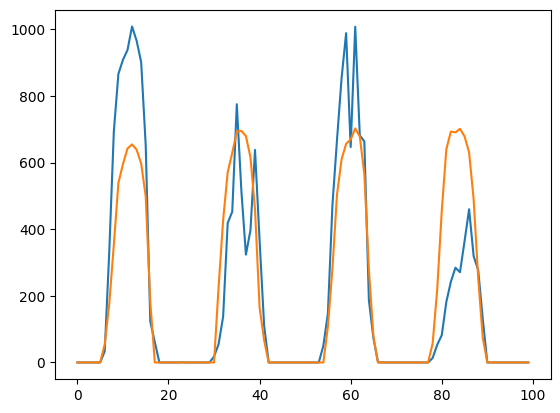

catboost MAPE loss : 24.395505147902714


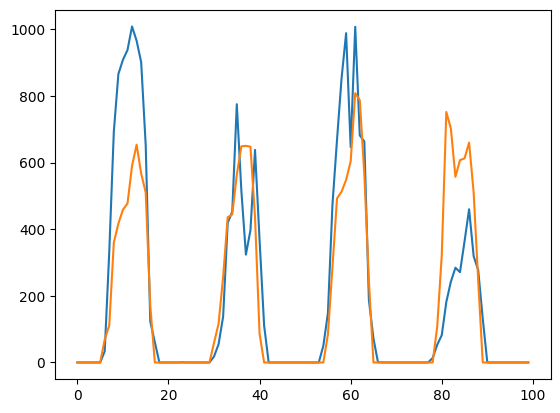

LGBM_R MAPE loss : 26.223545436819744%


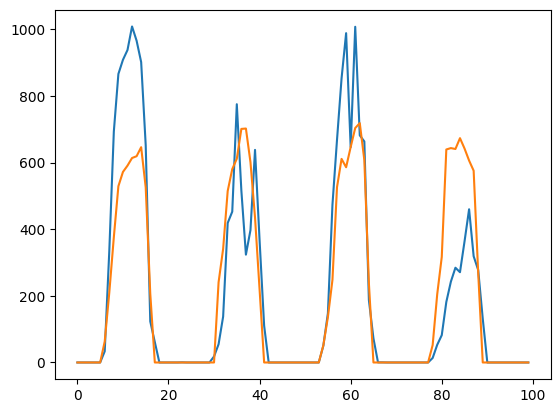

random_forest MAPE loss : 24.153947927936727%


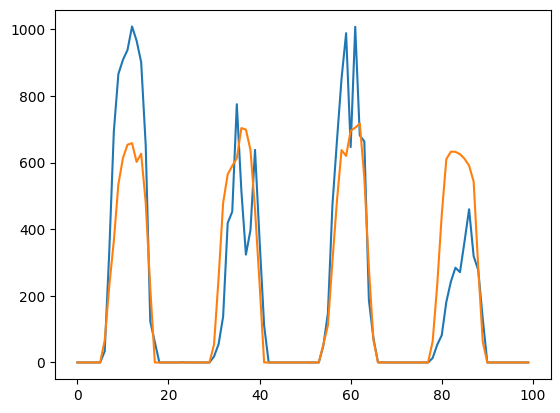

extra_trees MAPE loss : 24.25890945498948%


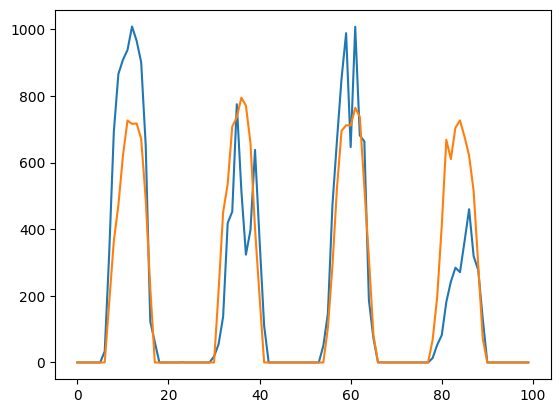

GradientBoosting MAPE loss : 25.739943655757415%


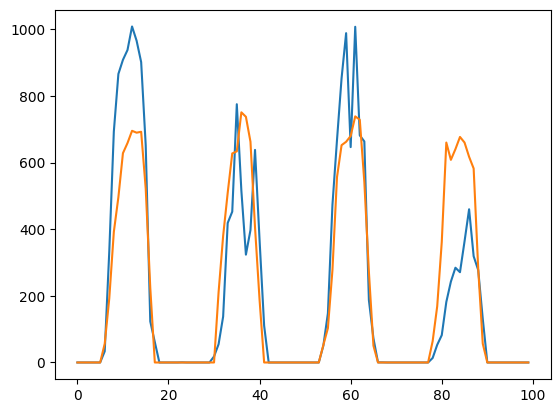

model_0 MAPE loss : 24.600982415657736%


In [7]:
catboost_y_pred, catboost_mape_loss, catboost_total_loss = score_compiler(catboost, test_x, test_y)
print(f'catboost MAPE loss : {catboost_total_loss*100}')

LGBM_R_y_pred, LGBM_R_mape_loss, LGBM_R_total_loss = score_compiler(LGBM_R, test_x, test_y)
print(f'LGBM_R MAPE loss : {LGBM_R_total_loss*100}%')

random_y_pred, random_mape_loss, random_total_loss = score_compiler(random_forest, test_x, test_y)
print(f'random_forest MAPE loss : {random_total_loss*100}%')

extra_y_pred, extra_mape_loss, extra_total_loss = score_compiler(extra_trees, test_x, test_y)
print(f'extra_trees MAPE loss : {extra_total_loss*100}%')

Gradient_y_pred, Gradient_mape_loss, Gradient_total_loss = score_compiler(GradientBoosting, test_x, test_y)
print(f'GradientBoosting MAPE loss : {Gradient_total_loss*100}%')

model_0_y_pred, model_0_mape_loss, model_0_total_loss = score_compiler(model_0, test_x, test_y)
print(f'model_0 MAPE loss : {model_0_total_loss*100}%')

In [8]:
def predict(config):
    final=(numpy.array(catboost_y_pred)*config['catboost']+
           numpy.array(LGBM_R_y_pred)*config['LGBM_R']+
           numpy.array(random_y_pred)*config['random']+
           numpy.array(extra_y_pred)*config['extra']+
           numpy.array(Gradient_y_pred)*config['Gradient']+
           numpy.array(model_0_y_pred)*config['model_0'])

    final/=sum(config.values())

    score = mean_absolute_percentage_error(test_y, final)*100
    r2 = r2_score(test_y, final)
    print(f"R² Score: {r2:}")
    print(f"MAPE Score: {100-score:}")
    return final

def submission_compiler(y_pred, test_y):
    mape_loss = []
    total_loss = mean_absolute_percentage_error(test_y, y_pred)
    for actual, predected in zip(y_pred, test_y):
        mape_loss.append(mean_absolute_percentage_error([predected], [actual]))
    return y_pred, numpy.array(mape_loss), total_loss

config={
    "catboost" : 0.4,
    "LGBM_R"   : 0.3,
    "random"   : 0.5,
    "extra"    : 0.4,
    "Gradient" : 0.3,
    "model_0"  : -0.2
}

final_y_pre = predict(config)
final_y_pred, final_mape_loss, final_total_loss = submission_compiler(final_y_pre, test_y)
print(f'MAPE Loss : {final_total_loss*100}%')

R² Score: 0.8982274444996382
MAPE Score: 76.47741649750654
MAPE Loss : 23.52258350249346%


In [9]:
def compute_monthwise_mape(submission_df):
    df = submission_df.copy()
    if not pd.api.types.is_datetime64_any_dtype(df['timestamp']):
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        
    df['year_month'] = df['timestamp'].dt.to_period('M')
    monthly_mape = df.groupby('year_month').agg({
        'mape': ['mean']
    })

    monthly_mape.columns = ['month_mape']
    monthly_mape = monthly_mape.reset_index()
    
    return monthly_mape

submission = pandas.DataFrame({'timestamp' : test['timestamp'], 
                               'predicted_ghi' : final_y_pred,
                               'actual_ghi' : test_y,
                               'mape' : final_mape_loss})

month_submission = compute_monthwise_mape(submission)

print(f"\nOverall statistics:")
print(f"Average monthly MAPE (Method 1): {month_submission['month_mape'].mean():.2f}%")


Overall statistics:
Average monthly MAPE (Method 1): 0.24%


In [10]:
submission.to_csv(f"Vigneshwaran.csv", index=False)
month_submission.to_csv(f"Month_Vigneshwaran.csv", index=False)

In [11]:
submission

,timestamp,predicted_ghi,actual_ghi,mape
0,1/1/2025 0:00,0.0,0.0,0.0
1,1/1/2025 1:00,0.0,0.0,0.0
2,1/1/2025 2:00,0.0,0.0,0.0
3,1/1/2025 3:00,0.0,0.0,0.0
4,1/1/2025 4:00,0.0,0.0,0.0
...,...,...,...,...
1387,2/27/2025 19:00,0.0,0.0,0.0
1388,2/27/2025 20:00,0.0,0.0,0.0
1389,2/27/2025 21:00,0.0,0.0,0.0
1390,2/27/2025 22:00,0.0,0.0,0.0


In [12]:
month_submission

,year_month,month_mape
0,2025-01,0.215633
1,2025-02,0.257722
